# Four-channel WDM: the Flexcompute reference in BeamZ

Recreate [Flexcompute's Autograd9WDM notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/): route **1270, 1290, 1310, and 1330 nm** into four output guides. This is the reference's **2D** lossless silicon/air model, not a full silicon-on-insulator stack. All geometry uses metres and all inverse-design features live in `beamz.optimization`.

The reference uses one broadband input, five training frequencies per channel, a smooth minimum across channels, an erosion/dilation penalty on the parameters, and 50 Adam updates. Beta increases from 1 to 50; leakage weight switches from 0 to 1 at zero-based step 17. BeamZ retains these choices.

**Numerical differences:** BeamZ uses a uniform 50 nm mesh instead of the reference's 15 nm design mesh and graded exterior. The 6 ps run is shorter than the reference's `200 / fwidth` maximum; spectral gradient evaluations check forward and adjoint decay. Full autodiff differentiates the configured finite window; a longer-duration verification follows optimization. Gaussian bandwidth conventions, Yee interpolation, filtering discretization, and mode normalization differ between solvers. This is a reproducible reference-problem recreation, not a claim of cross-solver numerical parity or fabrication readiness.

**Result from this execution:** all 50 updates completed. The continuous 50 nm model shows four separated passbands, but the binary export is sensitive to rerasterization: at 30 nm its desired-channel transmissions are **41.4%, 45.2%, 42.5%, and 15.1%**. The 6 and 12 ps values agree closely. This example validates the optimization workflow; it does **not** establish a mesh-converged device. The source aperture is 1.125 µm, slightly wider than the reference simulation's 1.0125 µm aperture.

## Setup
Use the repository's Python environment (`uv sync --extra dev`) as the notebook kernel. Everything runs locally through JAX. The execution below saves optimizer history and verification arrays under `results/topology_examples/tidy3d_wdm_4channel/`.

In [1]:
from pathlib import Path
import time, json, gc
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from beamz import (LIGHT_SPEED, Design, Material, Rectangle, Simulation, ModeSource,
                   ModeMonitor, FieldMonitor, FluxMonitor, ModeSpec, GaussianPulse, PML)
import beamz.optimization as opt

um = 1e-6
wavelengths_design = np.array([1.270, 1.290, 1.310, 1.330])*um
frequencies_design = LIGHT_SPEED / wavelengths_design
frequency = frequencies_design.mean()
fwidth = np.ptp(frequencies_design)
channel_width = abs(np.diff(frequencies_design).mean()) / 2
channel_frequencies = np.array([np.linspace(f-channel_width/2, f+channel_width/2, 5)
                                for f in frequencies_design])
training_frequencies = channel_frequencies.ravel()
output_y = (1.5 + np.linspace(.5625, 3.9375, 4))*um


root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"pyproject.toml").exists())
artifacts=root/"results/topology_examples/tidy3d_wdm_4channel"
artifacts.mkdir(parents=True,exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"font.size":10})
print("JAX:",jax.__version__,"backend:",jax.default_backend())


JAX: 0.9.0 backend: cpu


## Geometry, modal objective, and schedules
Rows of the power matrix represent output ports; columns represent wavelength bands. For each output, subtract the average leakage from the other three bands, then take `-logsumexp(-metrics)` with temperature 1, as in Tidy3D. Its absolute value can be negative; it is an optimization score, not transmission efficiency.

The objective uses source-normalized modal power as in the reference. An additional input monitor supports separately reported incident-normalized verification. The native `tm` label in BeamZ selects the 2D Ez field polarization.

Design parameters: (90, 90) 8100
Training frequencies: 20 timesteps: 51391


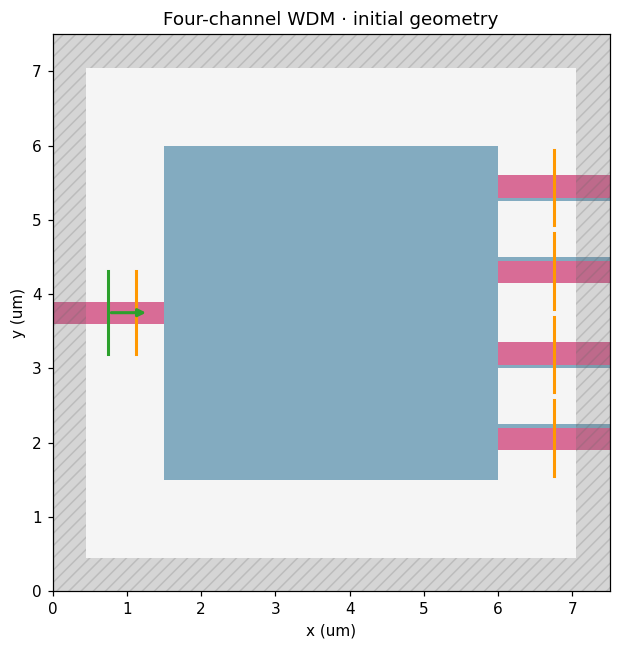

In [2]:
def make_wdm(resolution=50e-9, duration=6e-12, backend="adjoint", grouping="frequency"):
    air, silicon = Material(1), Material(3.49**2)
    geometry = Design(width=7.5*um, height=7.5*um, material=air)
    geometry += Rectangle(position=(0,3.6*um), width=1.5*um, height=.3*um, material=silicon)
    for y in output_y:
        geometry += Rectangle(position=(6*um,y-.15*um), width=1.5*um, height=.3*um, material=silicon)
    mode = ModeSpec(num_modes=1, polarization="tm")
    source = ModeSource(center=(.75*um,3.75*um,0),size=(0,1.125*um,um),direction="+",
        mode_spec=mode, source_time=GaussianPulse(freq0=frequency,fwidth=fwidth,offset=5/(2*np.pi)))
    outputs = [ModeMonitor(center=(6.75*um,y,0),size=(0,1.0125*um,um),freqs=training_frequencies,
                mode_spec=mode,name=f"mode_{i}") for i,y in enumerate(output_y)]
    incoming = ModeMonitor(center=(1.125*um,3.75*um,0),size=(0,1.125*um,um),
                           freqs=training_frequencies,mode_spec=mode,name="input")
    simulation = Simulation(design=geometry,resolution=resolution,run_time=duration,polarization="tm",
        sources=[source],monitors=[*outputs,incoming],boundaries=[PML(thickness=.45*um,formulation="cpml")])
    region = opt.TopologyDesignRegion(center=(3.75*um,3.75*um,0),size=(4.5*um,4.5*um,np.inf),
        pixel_size=resolution,eps_bounds=(1,3.49**2),transformations=[opt.FilterProject(radius=.1*um,beta=1)],
        penalties=[opt.ErosionDilationPenalty(length_scale=.1*um,beta=10)],penalty_input="parameters")
    return opt.InverseDesign(simulation,region,output_monitor_names=[f"mode_{i}" for i in range(4)],
        gradient_backend=backend,adjoint_source_grouping=grouping,checkpoint_interval=128)


def channel_powers(data):
    # Rows are output ports; columns are wavelength channels, five frequencies each.
    return jnp.stack([jnp.abs(data[f"mode_{i}"].amps.sel(direction="+",mode_index=0).values.reshape(4,5))**2
                      for i in range(4)]).mean(axis=-1)


def post_process(data, leak_weight=0.0):
    power = channel_powers(data)
    desired = jnp.diag(power)
    leakage = (power.sum(axis=1)-desired)/3
    return -logsumexp(-(desired-leak_weight*leakage))

schedule = opt.OptimizationSchedule(beta=opt.LinearSchedule(1,50,50),
    objective_kwargs={"leak_weight":opt.StepSchedule(0,1,17)})

design=make_wdm()
params0=design.design_region.initial_parameters
print("Design parameters:",params0.shape,params0.size)
print("Training frequencies:",len(training_frequencies),"timesteps:",len(design.simulation.time))
fig,ax=design.initial_simulation.plot(figsize=(7,6))
ax.set_title("Four-channel WDM · initial geometry")
plt.show()


## Independent gradient and source-grouping checks
On a 75 nm mesh, compare full autodiff, independent-frequency adjoints, and broadband source-basis adjoints at the same perturbed parameters and scheduled settings. A directional finite difference checks the full objective independently.

Tidy3D groups eligible sources by spatial port or frequency. BeamZ's optional `auto` strategy instead factors the actual frequency-dependent source profiles into a smaller spatial basis, accepting a reduction only when every normalized source is reconstructed within 1e-7. It retains complex spectral weights and measured pulse normalization, with an independent-frequency fallback. This avoids assuming a mode profile is frequency-independent.

In [3]:
check=make_wdm(resolution=75e-9,backend="autodiff")
probe=check.design_region.initial_parameters+.015*np.random.default_rng(7).normal(size=check.design_region.params_shape)
settings=schedule.values(20)
values,gradients,timings,diagnostics={},{},{},{}
for label,backend,grouping in [("autodiff","autodiff","frequency"),("frequency","adjoint","frequency"),("auto","adjoint","auto")]:
    candidate=check if label=="autodiff" else check.updated_copy(gradient_backend=backend,adjoint_source_grouping=grouping)
    fn=candidate.make_objective_fn(post_process,**settings)
    started=time.perf_counter()
    value,gradient=jax.value_and_grad(fn)(probe)
    gradients[label]=np.asarray(gradient)
    values[label]=float(value)
    timings[label]=time.perf_counter()-started
    if backend=="adjoint":diagnostics[label]=candidate.gradient_diagnostics
    print(label,"score",values[label],"seconds",timings[label],diagnostics.get(label,{}),flush=True)
gradient_errors={name:float(np.linalg.norm(g-gradients["autodiff"])/np.linalg.norm(gradients["autodiff"])) for name,g in gradients.items()}
direction=gradients["autodiff"]/np.linalg.norm(gradients["autodiff"])
fn=check.make_objective_fn(post_process,**settings)
h=.01
finite_difference=float((fn(probe+h*direction)-fn(probe-h*direction))/(2*h))
np.testing.assert_allclose(finite_difference,np.sum(gradients["autodiff"]*direction),rtol=.01,atol=1e-6)
assert max(gradient_errors.values())<.005
print("Relative gradient errors:",gradient_errors,"directional finite difference:",finite_difference)
del check,candidate,fn,gradients
jax.clear_caches();gc.collect()


autodiff score -2.417819023132324 seconds 22.110200957977213 {}


frequency score -2.417819023132324 seconds 194.67079983407166 {'terminal_field_ratio': 4.382339682251768e-07, 'decay_tolerance': 0.0001, 'adjoint_solves': 20, 'source_grouping': 'frequency', 'adjoint_terminal_field_ratios': (3.071326500503346e-05, 9.830492672335822e-06, 1.7653193935984746e-05, 8.878190783434547e-06, 2.360725193284452e-05, 1.6110636352095753e-05, 2.4313700123457238e-05, 1.9657851225929335e-05, 1.5726094716228545e-05, 2.414094160485547e-05, 1.9379991499590687e-05, 2.333591146452818e-05, 2.0966350348317064e-05, 1.1841348168672994e-05, 2.4600880351499654e-05, 1.755172161210794e-05, 2.401211895630695e-05, 2.1245694370009005e-05, 1.1032696420443244e-05, 1.4613307939725928e-05), 'adjoint_timesteps': (34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261), 'stored_design_dft_values': 74420}


auto score -2.417819023132324 seconds 198.08365995797794 {'terminal_field_ratio': 4.382339682251768e-07, 'decay_tolerance': 0.0001, 'adjoint_solves': 12, 'source_grouping': 'broadband_basis', 'source_basis_rank': 12, 'source_reconstruction_error': 8.104715908720145e-08, 'active_frequencies': 20, 'adjoint_terminal_field_ratios': (3.528527304297313e-05, 1.2401308595144656e-05, 1.7008251234074123e-05, 1.8966433344758116e-05, 2.6738709493656643e-05, 1.596302718098741e-05, 2.1747420760220848e-05, 3.006366932822857e-05, 2.4821179977152497e-05, 2.7630771000985987e-05, 1.7224763723788783e-05, 1.3552800737670623e-05), 'adjoint_timesteps': (34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261), 'stored_design_dft_values': 74420}


Relative gradient errors: {'autodiff': 0.0, 'frequency': 2.60916531260591e-05, 'auto': 2.764066266536247e-05} directional finite difference: 1.7119646072387695


1399

## Select and profile the training backend
Use the gradient-check timings to select a backend, then measure its cold and warmed gradient cost on the training mesh. Full autodiff can be faster for this modest 2D grid; the spectral adjoint offers different memory scaling. All routes use the same objective and schedules. Coarse timings are a heuristic, not a universal hardware benchmark.

In [4]:
chosen=min(timings,key=timings.get)
backend="autodiff" if chosen=="autodiff" else "adjoint"
grouping="auto" if chosen=="auto" else "frequency"
design=design.updated_copy(gradient_backend=backend,adjoint_source_grouping=grouping)
fn=design.make_objective_fn(post_process,**schedule.values(0))
elapsed=[]
for repeat in range(2):
    start=time.perf_counter()
    value,gradient=jax.value_and_grad(fn)(params0)
    np.asarray(gradient)
    elapsed.append(time.perf_counter()-start)
profile={"coarse_seconds":timings,"coarse_adjoint_diagnostics":diagnostics,
         "training_first_seconds":elapsed[0],"training_warm_seconds":elapsed[1]}
print("Selected backend:",chosen,"training profile:",profile,flush=True)


Selected backend: autodiff training profile: {'coarse_seconds': {'autodiff': 22.110200957977213, 'frequency': 194.67079983407166, 'auto': 198.08365995797794}, 'coarse_adjoint_diagnostics': {'frequency': {'terminal_field_ratio': 4.382339682251768e-07, 'decay_tolerance': 0.0001, 'adjoint_solves': 20, 'source_grouping': 'frequency', 'adjoint_terminal_field_ratios': (3.071326500503346e-05, 9.830492672335822e-06, 1.7653193935984746e-05, 8.878190783434547e-06, 2.360725193284452e-05, 1.6110636352095753e-05, 2.4313700123457238e-05, 1.9657851225929335e-05, 1.5726094716228545e-05, 2.414094160485547e-05, 1.9379991499590687e-05, 2.333591146452818e-05, 2.0966350348317064e-05, 1.1841348168672994e-05, 2.4600880351499654e-05, 1.755172161210794e-05, 2.401211895630695e-05, 2.1245694370009005e-05, 1.1032696420443244e-05, 1.4613307939725928e-05), 'adjoint_timesteps': (34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261, 34261)

## Optimize and demonstrate exact schedule continuation
The linear schedule has a fixed 50-update horizon, independent of how many updates are requested before a pause. Stop at 25, restore the saved Adam state, then finish to 50. Each callback records the actual beta and leakage weight, plus decay ratios and solve counts when using the spectral backend. No design symmetry is imposed: the reference assigns distinct wavelengths to distinct output ports.

In [5]:
optimizer = opt.AdamOptimizer(design=design, learning_rate=.1, schedule=schedule,
    objective_id="reference-wdm-four-channel-v1")
checkpoint = artifacts / "history.npz"
started = time.perf_counter()
progress_rows = []
def report(result):
    h = result.history[-1]
    row = dict(step=h.step, score=h.objective_before, post=h.post_process_val,
        penalty=h.penalty, elapsed=time.perf_counter()-started,
        **result.settings(), **(design.gradient_diagnostics or {}))
    progress_rows.append(row)
    (artifacts/"progress.json").write_text(json.dumps(progress_rows, indent=2))
    print(f"Step {row['step']:2d}: score={row['score']:.5f}, beta={row['beta']:.1f}, "
          f"leak={row['post_process_kwargs']['leak_weight']:.0f}, elapsed={row['elapsed']:.1f}s", flush=True)
partial = optimizer.run(post_process, steps=25, checkpoint=checkpoint,
                        checkpoint_every=5, callback=report)
restored = optimizer.load_result(checkpoint, post_process)
np.testing.assert_array_equal(partial.final_params, restored.final_params)
assert restored.settings()["beta"] == 25
result = optimizer.run(post_process, steps=50, resume=checkpoint,
                       checkpoint=checkpoint, checkpoint_every=5, callback=report)
optimization_seconds = time.perf_counter()-started
assert result.completed_steps == 50 and result.settings()["beta"] == 50
print("Completed all 50 updates with checkpoint continuation.")

Step  1: score=-2.34140, beta=1.0, leak=0, elapsed=87.9s


Step  2: score=-2.31254, beta=2.0, leak=0, elapsed=163.3s


Step  3: score=-2.31829, beta=3.0, leak=0, elapsed=242.0s


Step  4: score=-2.28579, beta=4.0, leak=0, elapsed=319.4s


Step  5: score=-2.13784, beta=5.0, leak=0, elapsed=378.9s


...

Step 47: score=-0.77100, beta=47.0, leak=1, elapsed=2182.0s


Step 48: score=-0.74979, beta=48.0, leak=1, elapsed=2211.8s


Step 49: score=-0.75550, beta=49.0, leak=1, elapsed=2242.3s


Step 50: score=-0.73598, beta=50.0, leak=1, elapsed=2272.7s


Completed all 50 updates with checkpoint continuation.


## History and final material
`result.to_simulation()` and `result.export_design()` use the final applied beta automatically. Historical states use their corresponding scheduled settings. Scores before and after the leakage switch have different definitions.

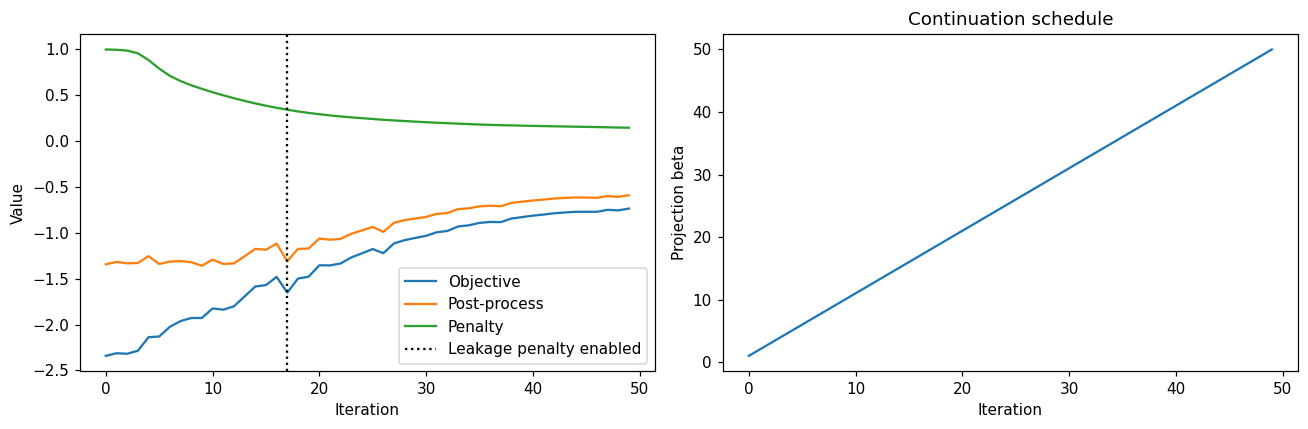

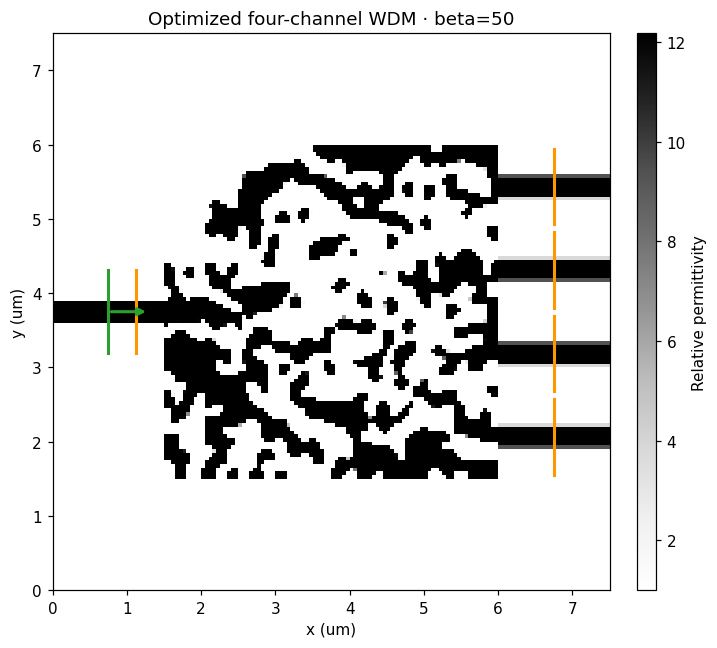

In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
result.plot_optimization(ax=axes[0])
axes[0].axvline(17,color="black",ls=":",label="Leakage penalty enabled")
axes[0].legend()
axes[1].plot([s["beta"] for s in result.schedule_history])
axes[1].set(xlabel="Iteration",ylabel="Projection beta",title="Continuation schedule")
fig.tight_layout();plt.show()
final_simulation=result.to_simulation()
fig,ax=final_simulation.plot_eps(z=0,figsize=(7,6))
ax.set_title("Optimized four-channel WDM · beta=50")
plt.show()


## Reference spectra and wavelength-resolved fields
As in Tidy3D, compute modal power, total flux, and a field map at each channel center. A fresh ordinary simulation samples 151 frequencies. Additional incident-normalized spectra are reported separately; values are not clipped. The source has a finite spectral range, so inspect the input spectrum before interpreting far-band tails.

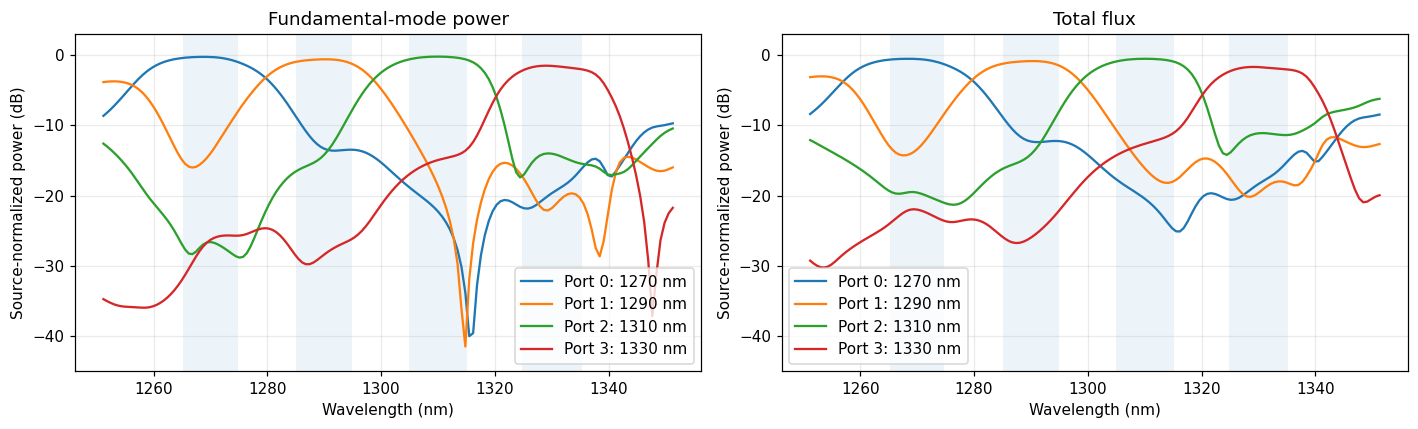

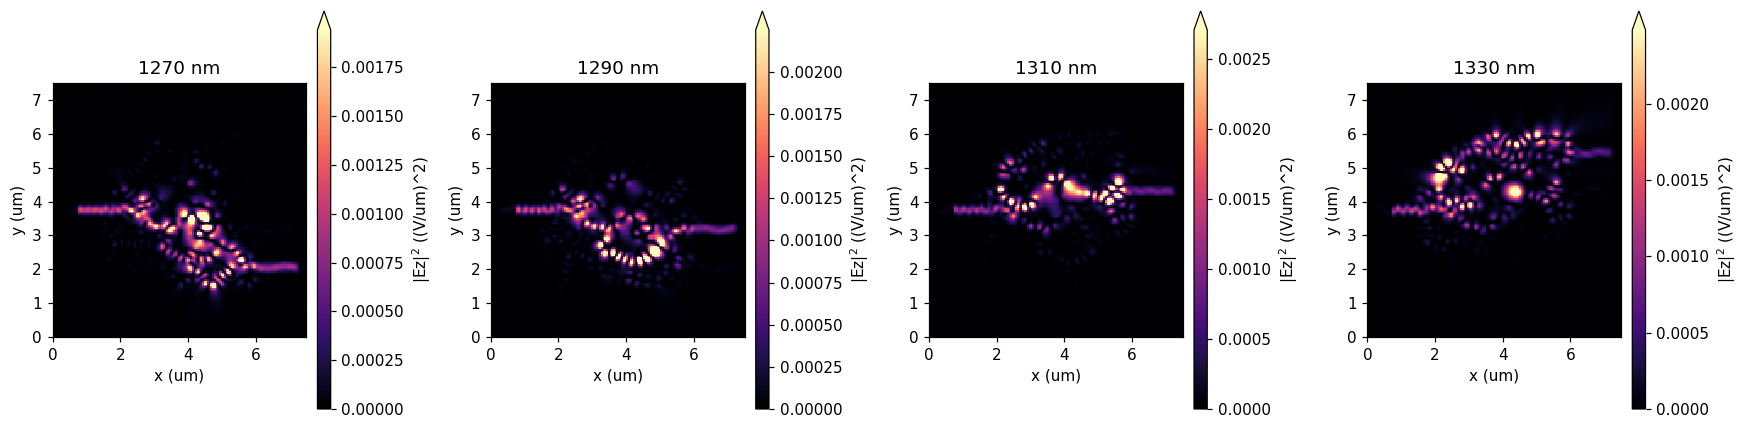

In [7]:
frequency_spacing=abs(np.diff(frequencies_design).mean())
freqs_measure=np.linspace(frequencies_design.min()-frequency_spacing,frequencies_design.max()+frequency_spacing,151)
mode_monitors=[m.updated_copy(freqs=freqs_measure) for m in final_simulation.monitors]
flux_monitors=[FluxMonitor(center=m.center,size=m.size,freqs=freqs_measure,name=f"flux_{i}") for i,m in enumerate(mode_monitors[:4])]
field_monitor=FieldMonitor(center=(3.75*um,3.75*um,0),size=(7.5*um,7.5*um,0),freqs=frequencies_design,fields=("Ez",),name="field")
verified=final_simulation.updated_copy(monitors=[*mode_monitors,*flux_monitors,field_monitor]).run(backend="jax",performance=False)
modal_power=np.stack([np.abs(verified.mode(f"mode_{i}").amps.sel(direction="+",mode_index=0).values).reshape(-1)**2 for i in range(4)])
incident_power=np.abs(verified.mode("input").amps.sel(direction="+",mode_index=0).values).reshape(-1)**2
flux_power=np.stack([np.asarray(verified[f"flux_{i}"].flux).reshape(-1) for i in range(4)])
wavelengths_nm=LIGHT_SPEED/freqs_measure/1e-9
fig,axes=plt.subplots(1,2,figsize=(13,4))
for ax,powers,title in [(axes[0],modal_power,"Fundamental-mode power"),(axes[1],flux_power,"Total flux")]:
    for i in range(4):
        ax.plot(wavelengths_nm,10*np.log10(np.maximum(powers[i],1e-15)),label=f"Port {i}: {wavelengths_design[i]/1e-9:.0f} nm")
        bounds=LIGHT_SPEED/channel_frequencies[i,[0,-1]]/1e-9
        ax.axvspan(min(bounds),max(bounds),alpha=.08)
    ax.set(xlabel="Wavelength (nm)",ylabel="Source-normalized power (dB)",title=title,ylim=(-45,3))
    ax.legend();ax.grid(alpha=.25)
fig.tight_layout();plt.show()
fig,axes=plt.subplots(1,4,figsize=(16,4))
for f,ax,w in zip(frequencies_design,axes,wavelengths_design):
    verified.plot_field("field",field_name="Ez",val="abs^2",frequency=f,ax=ax)
    ax.set_title(f"{w/1e-9:.0f} nm")
fig.tight_layout();plt.show()


## Binary export and independent verification
Threshold the final pattern into ordinary polygons. Compare the same geometry at 50 and 30 nm, and double the duration on the finer mesh. Report each channel's intended transmission, unwanted-port power, and isolation using independently measured incident power. This sensitivity study is not a proof of mesh convergence or fabrication readiness.

{'mesh_nm': 49.99999999999999, 'run_time_ps': 6.0, 'desired': [0.644935309269874, 0.7042425967562262, 0.8264931651368135, 0.24786979789317024], 'max_unwanted': [0.024510473800356026, 0.06990687032724444, 0.03852908658691345, 0.03588666139986678], 'isolation_db': [14.201644481051957, 10.032024306672337, 13.314505531602636, 8.392905556375966]}


{'mesh_nm': 29.999999999999996, 'run_time_ps': 6.0, 'desired': [0.4136358019644186, 0.45207343479825424, 0.42472186744168877, 0.15072356594966196], 'max_unwanted': [0.23832980108052843, 0.1967322957967204, 0.17362311868178026, 0.032556764982231215], 'isolation_db': [2.394397712640707, 3.613333272809944, 3.8849706895743106, 6.655399159960336]}


{'mesh_nm': 29.999999999999996, 'run_time_ps': 12.0, 'desired': [0.41363563550157706, 0.4520735678007773, 0.42472201021875194, 0.15072360391745937], 'max_unwanted': [0.23832985323051722, 0.19673226441147787, 0.17362315193581682, 0.03255677156014033], 'isolation_db': [2.394395014574828, 3.6133352433702663, 3.8849713177204177, 6.655399376496102]}


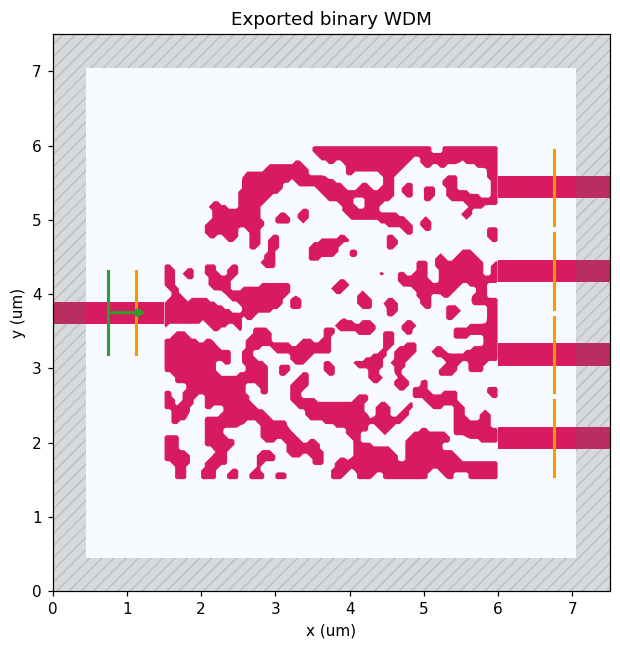

**Finer-grid binary verification:** desired channel transmissions = 41.4%, 45.2%, 42.5%, 15.1%. See the full per-channel leakage and mesh/duration comparisons above.

In [8]:
binary=result.export_design()
verification_rows=[]
for resolution,duration in [(50e-9,6e-12),(30e-9,6e-12),(30e-9,12e-12)]:
    sim=design.simulation.updated_copy(design=binary,resolution=resolution,run_time=duration)
    data=sim.run(backend="jax",performance=False)
    output=np.asarray(channel_powers({f"mode_{i}":data.mode(f"mode_{i}") for i in range(4)}))
    input_samples=np.abs(data.mode("input").amps.sel(direction="+",mode_index=0).values.reshape(4,5))**2
    normalized=np.stack([np.abs(data.mode(f"mode_{i}").amps.sel(direction="+",mode_index=0).values.reshape(4,5))**2/input_samples for i in range(4)]).mean(axis=-1)
    desired=np.diag(normalized)
    unwanted=normalized.copy();np.fill_diagonal(unwanted,0)
    isolation=10*np.log10(desired/np.maximum(unwanted.max(axis=0),1e-15))
    row=dict(mesh_nm=resolution/1e-9,run_time_ps=duration/1e-12,desired=desired.tolist(),max_unwanted=unwanted.max(axis=0).tolist(),isolation_db=isolation.tolist())
    verification_rows.append(row)
    print(row,flush=True)
fig,ax=sim.plot(figsize=(7,6));ax.set_title("Exported binary WDM");plt.show()
metrics=dict(gradient_errors=gradient_errors,profile=profile,gradient_backend=design.gradient_backend,adjoint_source_grouping=design.adjoint_source_grouping,optimization_seconds=optimization_seconds,verification=verification_rows)
(artifacts/"metrics.json").write_text(json.dumps(metrics,indent=2))
np.savez_compressed(artifacts/"spectra.npz",frequencies=freqs_measure,modal_power=modal_power,incident_power=incident_power,flux_power=flux_power)
display(Markdown("**Finer-grid binary verification:** desired channel transmissions = "+", ".join(f"{v:.1%}" for v in verification_rows[-1]["desired"])+". See the full per-channel leakage and mesh/duration comparisons above."))


## What this adds to BeamZ
Reusable projection/penalty/objective schedules, schedule-aware checkpoint continuation and export, optional broadband source-basis adjoints, and a direct four-channel WDM reference example. Both gradient backends share the same `beamz.optimization` workflow. General shape derivatives, dispersive material gradients, and multiple independent input excitations remain separate features.

Source: Flexcompute, *Adjoint optimization of a wavelength division multiplexer*, `Autograd9WDM.ipynb`, accessed 2026-09-21. It cites Cheung et al., *Inverse-designed CWDM demultiplexer operated in O-band*, OFC 2024. No Tidy3D cloud simulation was run.